# Airspace Closure Impact Forecasting with a Lightweight LSTM

## Introduction

In late February 2026, U.S. and Israeli strikes on Iran and subsequent Iranian retaliation forced large parts of Middle Eastern airspace to close or face heavy restrictions. Major Gulf carriers -- Emirates, Etihad, flydubai, and Qatar Airways -- were reduced to operating only limited flights out of the UAE and Qatar [1]. According to Cirium data reported by Airways Magazine, roughly 53% of outbound Middle Eastern flights were cancelled between February 28 and March 7, with a peak cancellation rate of about 66% on March 3 [2]. By March 7, the outbound cancellation rate had fallen to around 24%, showing a sharp but incomplete recovery [2]. Dubai Airports reported handling over 1,140 flights across Dubai International and Al Maktoum airports during an 84-hour window between March 2 and 5, including over 500 outbound flights to more than 80 destinations [1].

The disruption goes beyond flight numbers. Stranded passengers across the Gulf needed special repatriation services -- Indian carriers like Air India and Air India Express mounted special flights on March 7 to bring passengers home [3]. Airlines deployed commercial policy as a shock absorber: Emirates restored around 60% of its network and offered flexible rebooking options through late March [1]. These recovery dynamics -- how quickly a hub returns to normal operations after an airspace closure -- matter for airline operations controllers, network planners, and passengers trying to rebook.

In this notebook, we build a lightweight Long Short-Term Memory (LSTM) neural network to forecast airspace closure recovery trajectories. Given a time series of hourly cancellation rates and related features, the model predicts how the next 6 hours will unfold. This gives us a practical tool to answer: after a closure event hits, how quickly will things get back to normal?

## Environment Setup

This demo runs on a Mac with an M-series chip.

**Prerequisite:**
Install [Miniconda](https://www.anaconda.com/docs/getting-started/miniconda/install).

**Terminal commands to create the environment:**
```bash
# Create and activate the conda environment
conda create -n airspace-closure python=3.10 -y
conda activate airspace-closure

# Install core libraries
conda install -c conda-forge numpy pandas matplotlib seaborn scikit-learn jupyter jupyterlab ipython pillow ipywidgets -y

# Install PyTorch with MPS support
conda install pytorch torchvision torchaudio -c pytorch -y

pip install pymupdf

# Register the kernel
python -m ipykernel install --user --name airspace-closure --display-name "Python (airspace-closure)"

# Clear cache
conda clean -a -y && pip cache purge
```

In [1]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Interactive widgets
import ipywidgets as widgets
from ipywidgets import interact, interactive, FloatSlider, IntSlider, Dropdown, Button, Output

# Display utilities
import pymupdf as fitz
from IPython.display import Image as IPythonImage
from IPython.display import display, SVG

# Set pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.precision', 2)

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Device configuration
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: mps
PyTorch version: 2.5.1


In [2]:
# Utility function to display image (png, jpg, pdf, svg) in Jupyter
def show_image(image_path, width=500, page_num=0, dpi=300):
    if image_path.lower().endswith('.pdf'):
        doc = fitz.open(image_path)
        page = doc.load_page(page_num)
        pix = page.get_pixmap(dpi=dpi)
        img_data = pix.tobytes("png")
        doc.close()
        display(IPythonImage(data=img_data, width=width))
    elif image_path.lower().endswith('.svg'):
        display(SVG(image_path))
    else:
        display(IPythonImage(filename=image_path, width=width))

## Demo Pipeline


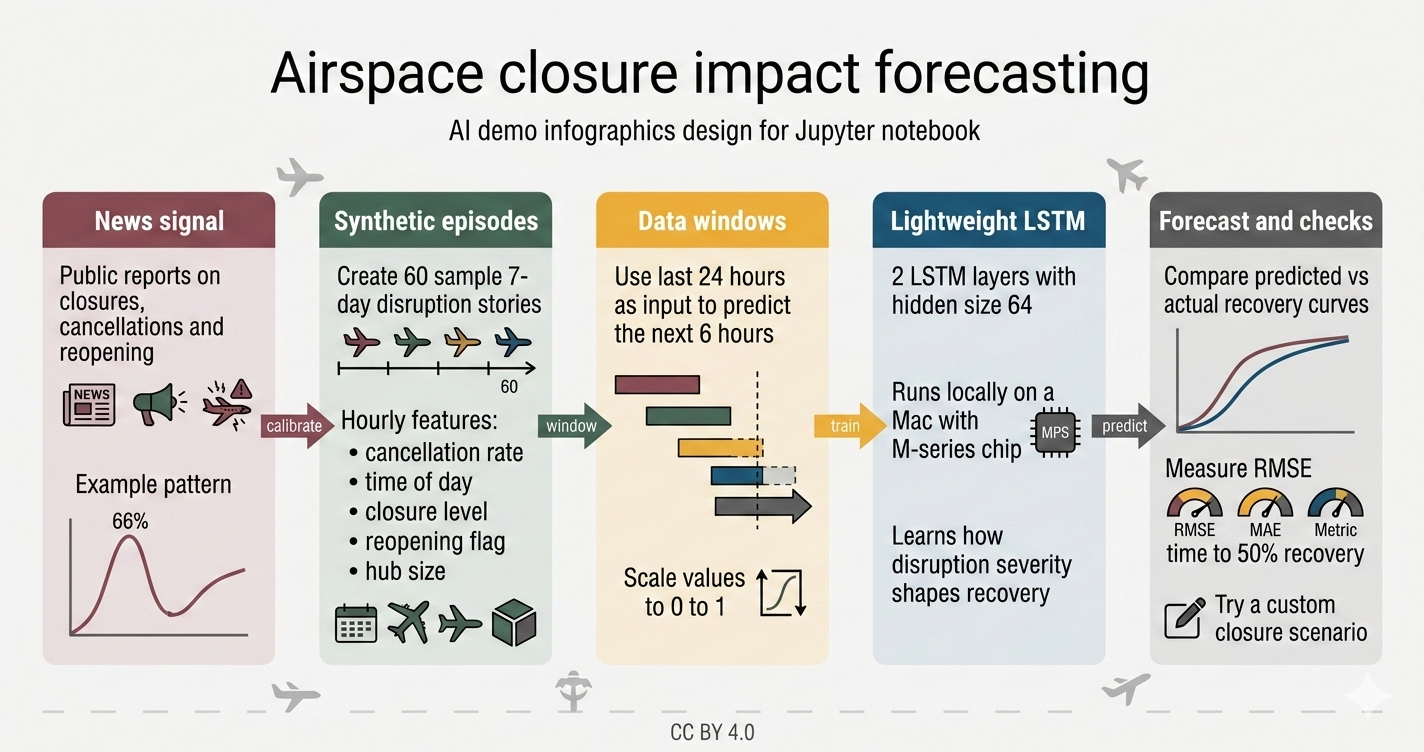

In [26]:
show_image('assets/pipeline-dev.png', width=900)

**Figure:** End-to-end flow of the demo. Public reports on closures, cancellations, and reopening patterns are turned into synthetic hourly disruption episodes. Those episodes are split into 24-hour inputs and 6-hour targets, then used to train a lightweight LSTM on a local MacBook. The trained model is checked against held-out recovery curves and then reused in an interactive scenario tool to estimate how fast cancellations may fall after a new closure event.


## What is an LSTM?

### Recurrent Neural Networks: Processing Data in Sequence

Standard neural networks process each input independently. But flight cancellation data is sequential -- what happened at hour 10 affects what happens at hour 11, 12, and beyond. A **Recurrent Neural Network (RNN)** handles this by processing data one timestep at a time, passing information forward from each step to the next. Think of it like an airline operations controller reviewing hourly status reports: each new report builds on what they already know from previous hours.

At each timestep $t$, an RNN takes two inputs: the current data $x_t$ and a "memory" from the previous step $h_{t-1}$. It combines them to produce an updated memory $h_t$:

$$h_t = \tanh(W_h h_{t-1} + W_x x_t + b)$$

This works well for short sequences, but it runs into trouble with longer ones.

### The Vanishing Gradient Problem

When training an RNN over long sequences (say, 168 hours of data), the model needs to learn how early events influence later ones. During training, this learning signal gets multiplied many times as it travels backward through the sequence. These repeated multiplications tend to shrink the signal to near-zero -- a phenomenon called the **vanishing gradient problem**. The result: standard RNNs struggle to learn long-range dependencies. For recovery forecasting, this is a problem because how severely airspace closed on day 1 directly affects recovery patterns on days 4, 5, and 6.

### LSTM: Learning What to Remember and What to Forget

The **Long Short-Term Memory (LSTM)** network, introduced by Hochreiter and Schmidhuber [4], solves this by adding a dedicated memory cell $C_t$ and three gates that control information flow. Consider again the airline operations controller. They cannot remember every single detail from every hourly report. Instead, they need to:

- **Forget** outdated information (a runway that was closed but has since reopened),
- **Store** new relevant facts (a fresh wave of cancellations just reported), and
- **Output** only what is relevant right now (the current recovery status to report to management).

An LSTM does exactly this with three gates:

**Forget gate** -- decides what old information to discard from the cell state:
$$f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)$$

**Input gate** -- decides what new information to store:
$$i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)$$
$$\tilde{C}_t = \tanh(W_C [h_{t-1}, x_t] + b_C)$$

**Cell state update** -- combines old (filtered) memory with new information:
$$C_t = f_t \odot C_t + i_t \odot \tilde{C}_t$$

**Output gate** -- decides what to output from the current cell state:
$$o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)$$
$$h_t = o_t \odot \tanh(C_t)$$

Here, $\sigma$ is the sigmoid function (outputs values between 0 and 1, acting as a "how much to let through" control), and $\odot$ is element-wise multiplication.

### Why LSTM for Recovery Forecasting?

Airspace closure recovery is not memoryless. The shape and speed of recovery depend on factors that stretch across days: how severe the initial closure was, how long it lasted, when government reopening announcements were made, and what the hub size is. An LSTM can retain these long-term patterns through its cell state while also reacting to short-term changes (like a secondary closure spike) through its gates. This makes it a natural fit for predicting multi-hour-ahead cancellation rates from historical patterns.

## LSTM Memory View


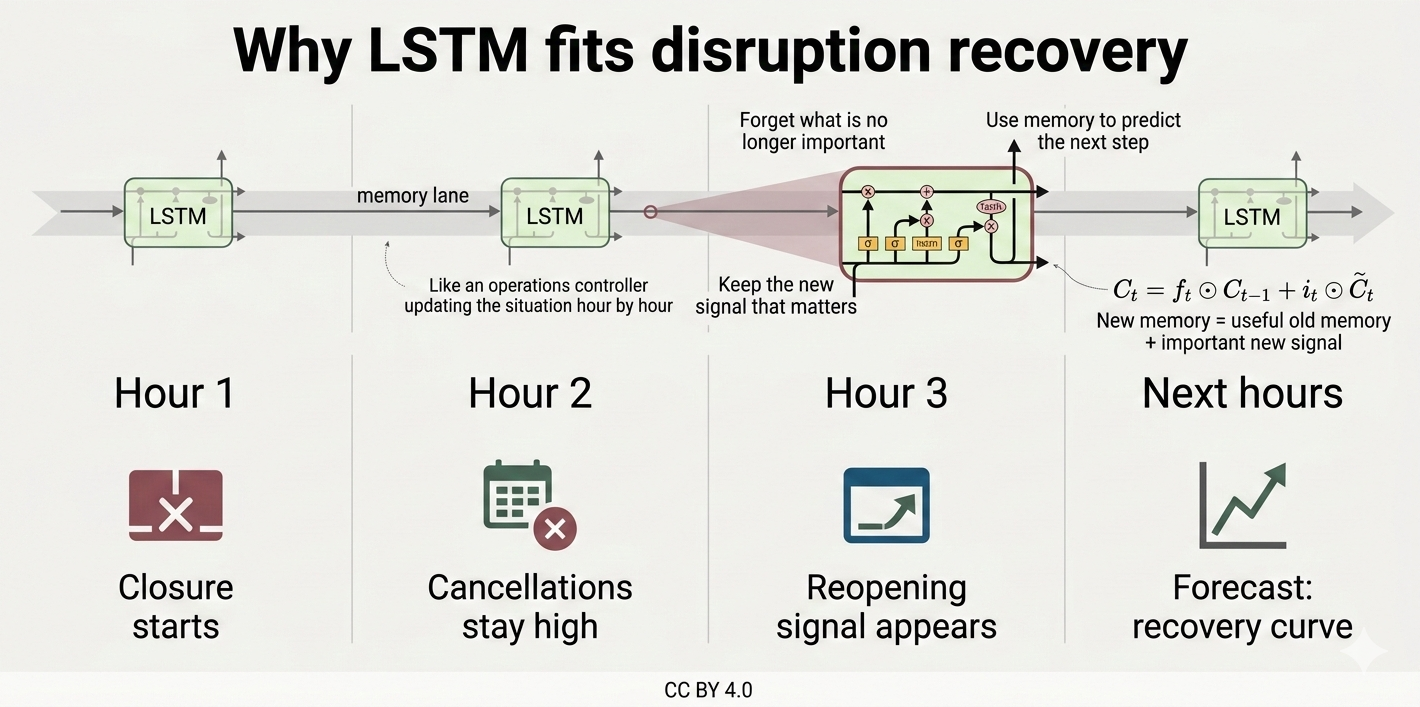

In [27]:
show_image('assets/aitheory-dev.png', width=900)

**Figure:** Simplified view of why an LSTM works well for this task. Each new hour adds a fresh signal, while the memory path carries forward the earlier disruption story. That lets the model connect the start of the closure, the persistence of high cancellations, and the reopening signal when it estimates the next part of the recovery curve.


## Dataset

> **DISCLAIMER**: All data in this notebook is **synthetic and hypothetical**. The generated episodes are rough approximations calibrated against publicly reported aggregate statistics (e.g., peak cancellation ~66% on March 3, recovery to ~24% by March 7 [2]). This data does not represent actual airline operational data. This demonstration is for educational purposes only to illustrate AI concepts.

We generate 60 synthetic airspace-closure-and-recovery episodes. Each episode represents 168 hours (7 days) of hourly observations at a hypothetical hub airport. The episodes model the lifecycle of an airspace closure event:

1. **Pre-closure baseline** -- normal operations with low cancellation rates (~2-8%).
2. **Closure onset** -- a sudden spike in cancellations modeled as a step function, with peak rates between 55% and 80% (calibrated to the ~66% peak observed on March 3 [2]).
3. **Recovery phase** -- an exponential decay back toward normal, with rate parameter $\lambda$ controlling how fast the hub recovers. The decay formula: $\text{rate}(t) = \text{peak} \cdot e^{-\lambda (t - t_{\text{recovery}})}$
4. **Realistic noise** -- secondary closure spikes (representing follow-up military activity or delays in reopening corridors), weekend effects (slightly higher cancellation rates), and Gaussian noise.

Each timestep carries 6 features:

| Feature | Description |
|---|---|
| `cancellation_rate` | Fraction of flights cancelled (0.0 to 1.0) |
| `hour_sin` | Sine of hour-of-day (cyclical encoding) |
| `hour_cos` | Cosine of hour-of-day (cyclical encoding) |
| `closure_intensity` | 0 = open, 1 = partial closure, 2 = full closure |
| `recovery_day_flag` | 1 when a government reopening announcement is active |
| `hub_size` | 0 = small, 1 = medium, 2 = large (constant per episode) |

The cyclical encoding of hour-of-day uses sine and cosine transforms so the model understands that hour 23 and hour 0 are adjacent, not 23 hours apart:

$$\text{hour\_sin} = \sin\left(\frac{2\pi \cdot \text{hour}}{24}\right), \quad \text{hour\_cos} = \cos\left(\frac{2\pi \cdot \text{hour}}{24}\right)$$

In [3]:
def generate_episode(episode_id, total_hours=168):
    """
    Generate one synthetic airspace-closure-and-recovery episode.
    Returns a DataFrame with 168 rows (hourly) and 6 feature columns.
    """
    # Random hub size (0=small, 1=medium, 2=large)
    hub_size = np.random.choice([0, 1, 2], p=[0.3, 0.4, 0.3])

    # Closure parameters
    closure_start = np.random.randint(0, 25)  # closure starts in first 24 hours
    closure_duration = np.random.randint(12, 73)  # 12-72 hours of closure
    peak_rate = np.random.uniform(0.55, 0.80)  # peak cancellation rate

    # Larger hubs recover slightly faster (more resources, more alternate routing)
    lambda_base = np.random.uniform(0.02, 0.08)
    lambda_recovery = lambda_base * (1 + 0.1 * hub_size)

    # Recovery start = end of closure
    recovery_start = closure_start + closure_duration

    # Government reopening announcement: happens around recovery start (within a few hours)
    reopen_announce_hour = recovery_start + np.random.randint(-2, 4)
    reopen_announce_hour = max(0, reopen_announce_hour)

    # Build the time series
    hours = np.arange(total_hours)
    cancellation_rate = np.zeros(total_hours)
    closure_intensity = np.zeros(total_hours, dtype=int)
    recovery_day_flag = np.zeros(total_hours, dtype=int)

    for t in range(total_hours):
        if t < closure_start:
            # Pre-closure baseline: low cancellation rate
            cancellation_rate[t] = np.random.uniform(0.02, 0.08)
            closure_intensity[t] = 0

        elif t < recovery_start:
            # During closure: ramp up quickly then plateau near peak
            hours_into_closure = t - closure_start
            ramp_up_hours = min(6, closure_duration // 3)

            if hours_into_closure < ramp_up_hours:
                # Ramp up to peak
                frac = hours_into_closure / max(ramp_up_hours, 1)
                cancellation_rate[t] = 0.05 + frac * (peak_rate - 0.05)
            else:
                # At or near peak with small fluctuations
                cancellation_rate[t] = peak_rate + np.random.uniform(-0.05, 0.05)

            # Closure intensity based on cancellation level
            if cancellation_rate[t] >= 0.50:
                closure_intensity[t] = 2  # full closure
            elif cancellation_rate[t] >= 0.25:
                closure_intensity[t] = 1  # partial closure
            else:
                closure_intensity[t] = 0

        else:
            # Recovery phase: exponential decay
            hours_since_recovery = t - recovery_start
            cancellation_rate[t] = peak_rate * np.exp(-lambda_recovery * hours_since_recovery)

            # Secondary closure spikes (10% probability during early recovery)
            if hours_since_recovery < 48 and np.random.random() < 0.10:
                spike = np.random.uniform(0.05, 0.15)
                cancellation_rate[t] += spike

            # Weekend effect: slightly higher cancellations on weekends
            day_of_week = (t // 24) % 7
            if day_of_week >= 5:  # Saturday, Sunday
                cancellation_rate[t] += np.random.uniform(0.01, 0.04)

            # Closure intensity based on current level
            if cancellation_rate[t] >= 0.50:
                closure_intensity[t] = 2
            elif cancellation_rate[t] >= 0.25:
                closure_intensity[t] = 1
            else:
                closure_intensity[t] = 0

        # Recovery day flag: active from announcement hour onward
        if t >= reopen_announce_hour and t >= recovery_start:
            recovery_day_flag[t] = 1

    # Add Gaussian noise
    noise = np.random.normal(0, 0.03, total_hours)
    cancellation_rate = cancellation_rate + noise

    # Clip to valid range
    cancellation_rate = np.clip(cancellation_rate, 0.0, 1.0)

    # Cyclical encoding of hour-of-day
    hour_of_day = hours % 24
    hour_sin = np.sin(2 * np.pi * hour_of_day / 24)
    hour_cos = np.cos(2 * np.pi * hour_of_day / 24)

    # Build DataFrame
    df = pd.DataFrame({
        'episode_id': episode_id,
        'hour': hours,
        'cancellation_rate': cancellation_rate,
        'hour_sin': hour_sin,
        'hour_cos': hour_cos,
        'closure_intensity': closure_intensity,
        'recovery_day_flag': recovery_day_flag,
        'hub_size': hub_size
    })

    return df

generate_episode() defined.


In [4]:
# Generate 60 synthetic episodes
np.random.seed(42)  # reproducibility
n_episodes = 60
episodes = []

for i in range(n_episodes):
    ep = generate_episode(episode_id=i)
    episodes.append(ep)

# Combine into one DataFrame
all_data = pd.concat(episodes, ignore_index=True)

print(f"Generated {n_episodes} episodes")
print(f"Total rows: {len(all_data):,} ({n_episodes} episodes x 168 hours)")
print(f"\nFeature summary:")
print(all_data[['cancellation_rate', 'hour_sin', 'hour_cos',
                'closure_intensity', 'recovery_day_flag', 'hub_size']].describe().round(3))

Generated 60 episodes
Total rows: 10,080 (60 episodes x 168 hours)

Feature summary:
       cancellation_rate  hour_sin  hour_cos  closure_intensity  \
count           10080.00  10080.00  10080.00           10080.00   
mean                0.29     -0.00     -0.00               0.71   
std                 0.28      0.71      0.71               0.89   
min                 0.00     -1.00     -1.00               0.00   
25%                 0.05     -0.71     -0.71               0.00   
50%                 0.15      0.00     -0.00               0.00   
75%                 0.58      0.71      0.71               2.00   
max                 0.93      1.00      1.00               2.00   

       recovery_day_flag  hub_size  
count           10080.00  10080.00  
mean                0.65      0.92  
std                 0.48      0.71  
min                 0.00      0.00  
25%                 0.00      0.00  
50%                 1.00      1.00  
75%                 1.00      1.00  
max            

In [5]:
# Plot 3 sample episodes to verify realistic patterns
sample_ids = [0, 15, 42]
colors = ['#1B587C', '#8D4F58', '#426556']

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

for idx, (ep_id, color) in enumerate(zip(sample_ids, colors)):
    ep_data = all_data[all_data['episode_id'] == ep_id]
    ax = axes[idx]

    # Plot cancellation rate
    ax.plot(ep_data['hour'], ep_data['cancellation_rate'],
            color=color, linewidth=1.5, label='Cancellation Rate')

    # Shade closure intensity regions
    for t in range(len(ep_data)):
        row = ep_data.iloc[t]
        if row['closure_intensity'] == 2:
            ax.axvspan(row['hour'] - 0.5, row['hour'] + 0.5,
                       alpha=0.08, color='#8D4F58')
        elif row['closure_intensity'] == 1:
            ax.axvspan(row['hour'] - 0.5, row['hour'] + 0.5,
                       alpha=0.05, color='#F1AE35')

    # Mark recovery announcement
    recovery_start = ep_data[ep_data['recovery_day_flag'] == 1]['hour'].min()
    if not np.isnan(recovery_start):
        ax.axvline(x=recovery_start, color='#426556', linestyle='--',
                   alpha=0.7, linewidth=1)
        ax.text(recovery_start + 1, 0.85, 'Reopening\nannounced',
                fontsize=9, color='#426556', fontfamily='sans-serif')

    # Reference lines from real data
    ax.axhline(y=0.66, color='#555555', linestyle=':', alpha=0.4, linewidth=0.8)
    ax.axhline(y=0.24, color='#555555', linestyle=':', alpha=0.4, linewidth=0.8)

    hub_labels = {0: 'Small', 1: 'Medium', 2: 'Large'}
    hub_val = ep_data['hub_size'].iloc[0]
    ax.set_ylabel('Cancellation Rate', fontsize=12, fontfamily='sans-serif')
    ax.set_title(f'Episode {ep_id} ({hub_labels[hub_val]} Hub)',
                 fontsize=13, fontfamily='sans-serif', fontweight='bold')
    ax.set_ylim(-0.05, 1.05)
    ax.tick_params(labelsize=10)
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel('Hour', fontsize=12, fontfamily='sans-serif')

# Add reference annotations on last subplot
axes[-1].annotate('~66% peak (Mar 3 data)', xy=(10, 0.66),
                  fontsize=8, color='#555555', fontfamily='sans-serif')
axes[-1].annotate('~24% recovery (Mar 7 data)', xy=(10, 0.24),
                  fontsize=8, color='#555555', fontfamily='sans-serif')

plt.tight_layout()
os.makedirs('assets', exist_ok=True)
plt.savefig('assets/sample_episodes-dev.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.close()
print("Saved: assets/sample_episodes-dev.png")

Saved: assets/sample_episodes-dev.png


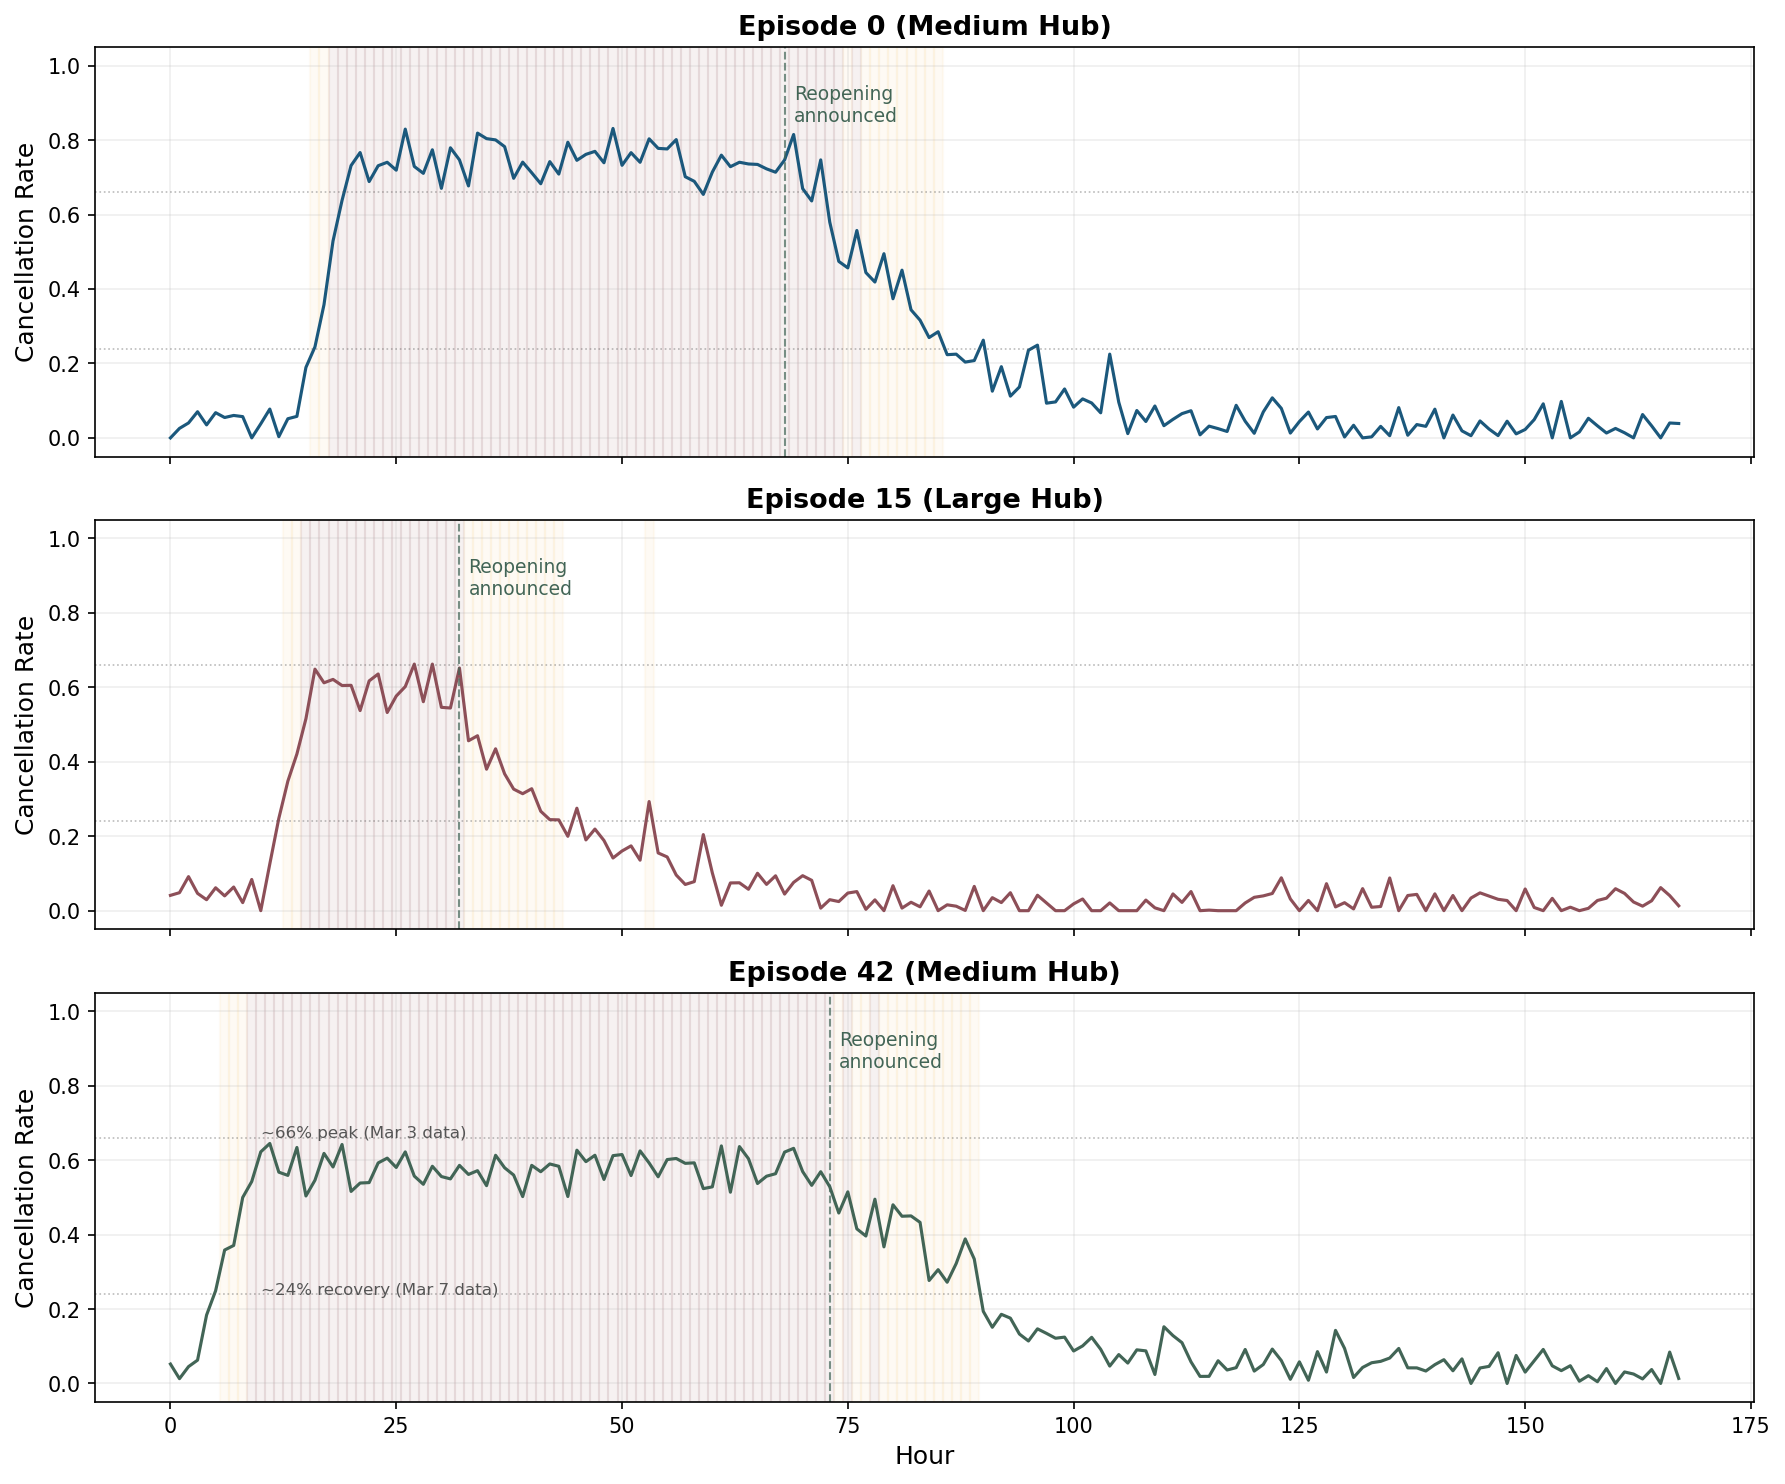

In [6]:
show_image('assets/sample_episodes-dev.png', width=700)

**Figure:** Three sample synthetic episodes showing hourly cancellation rates over 7 days. Each episode shows the characteristic pattern: low baseline, rapid spike during closure (red/yellow shaded regions indicate full/partial closure intensity), and exponential decay recovery after the reopening announcement (green dashed line). Episode 0 shows a long closure (~50 hours) with a high peak at a medium hub. Episode 15 shows a shorter closure at a large hub that recovers faster. Episode 42 shows a prolonged closure (~60 hours) at a medium hub with secondary spikes during recovery. Dotted gray lines mark the reported ~66% peak (March 3) and ~24% recovery (March 7) benchmarks from Cirium data [2].

## Data Preparation

Before feeding data into the LSTM, we need to do three things: split at the episode level, normalize features, and create sliding windows.

**Episode-level splitting.** We split the 60 episodes into train (36 episodes), validation (12 episodes), and test (12 episodes). The split happens at the episode level, not at the individual window level. If we split windows randomly, windows from the same episode could end up in both training and test sets. Since consecutive windows overlap heavily (they share 23 of 24 hours), this would leak information and inflate test performance. Episode-level splitting prevents this.

**Normalization.** Neural networks train more effectively when all input features are on a similar scale. We normalize each feature to [0, 1] using min-max scaling. The scaler is fit only on training data, then applied to validation and test sets. This prevents information leakage from the validation/test distributions into training.

**Sliding windows.** We use a sliding window approach: the model receives 24 consecutive hours of data (24 timesteps, each with 6 features) and predicts the cancellation rate for the next 6 hours. The window slides one hour at a time within each episode, producing many training examples from each episode.

In [7]:
from sklearn.preprocessing import MinMaxScaler

# --- Episode-level split ---
episode_ids = np.arange(n_episodes)
np.random.seed(42)
np.random.shuffle(episode_ids)

n_train = 36  # 60%
n_val = 12    # 20%
n_test = 12   # 20%

train_ids = episode_ids[:n_train]
val_ids = episode_ids[n_train:n_train + n_val]
test_ids = episode_ids[n_train + n_val:]

train_data = all_data[all_data['episode_id'].isin(train_ids)].copy()
val_data = all_data[all_data['episode_id'].isin(val_ids)].copy()
test_data = all_data[all_data['episode_id'].isin(test_ids)].copy()

print(f"Train: {len(train_ids)} episodes ({len(train_data):,} rows)")
print(f"Val:   {len(val_ids)} episodes ({len(val_data):,} rows)")
print(f"Test:  {len(test_ids)} episodes ({len(test_data):,} rows)")

# --- Normalization: fit on train only ---
feature_cols = ['cancellation_rate', 'hour_sin', 'hour_cos',
                'closure_intensity', 'recovery_day_flag', 'hub_size']

scaler = MinMaxScaler()
scaler.fit(train_data[feature_cols])

train_data[feature_cols] = scaler.transform(train_data[feature_cols])
val_data[feature_cols] = scaler.transform(val_data[feature_cols])
test_data[feature_cols] = scaler.transform(test_data[feature_cols])

print(f"\nFeatures normalized to [0, 1] using MinMaxScaler (fit on train only)")
print(f"Feature columns: {feature_cols}")

Train: 36 episodes (6,048 rows)
Val:   12 episodes (2,016 rows)
Test:  12 episodes (2,016 rows)

Features normalized to [0, 1] using MinMaxScaler (fit on train only)
Feature columns: ['cancellation_rate', 'hour_sin', 'hour_cos', 'closure_intensity', 'recovery_day_flag', 'hub_size']


In [8]:
# --- Sliding window function ---
INPUT_WINDOW = 24   # hours of input
OUTPUT_WINDOW = 6   # hours to predict

def create_windows(df, feature_cols, input_window=24, output_window=6):
    """
    Create sliding windows from episode data.
    Input: (input_window, n_features) -> Output: (output_window,) cancellation_rate only.
    """
    X_windows = []
    y_windows = []

    for ep_id in df['episode_id'].unique():
        ep = df[df['episode_id'] == ep_id][feature_cols].values
        total_len = len(ep)

        for start in range(total_len - input_window - output_window + 1):
            x = ep[start:start + input_window]
            # Target: cancellation_rate (first column) for the next output_window hours
            y = ep[start + input_window:start + input_window + output_window, 0]
            X_windows.append(x)
            y_windows.append(y)

    return np.array(X_windows, dtype=np.float32), np.array(y_windows, dtype=np.float32)

X_train, y_train = create_windows(train_data, feature_cols, INPUT_WINDOW, OUTPUT_WINDOW)
X_val, y_val = create_windows(val_data, feature_cols, INPUT_WINDOW, OUTPUT_WINDOW)
X_test, y_test = create_windows(test_data, feature_cols, INPUT_WINDOW, OUTPUT_WINDOW)

print(f"Sliding windows created (input: {INPUT_WINDOW}h, output: {OUTPUT_WINDOW}h):")
print(f"  Train: {X_train.shape[0]:,} windows | X shape: {X_train.shape} | y shape: {y_train.shape}")
print(f"  Val:   {X_val.shape[0]:,} windows | X shape: {X_val.shape} | y shape: {y_val.shape}")
print(f"  Test:  {X_test.shape[0]:,} windows | X shape: {X_test.shape} | y shape: {y_test.shape}")

Sliding windows created (input: 24h, output: 6h):
  Train: 5,004 windows | X shape: (5004, 24, 6) | y shape: (5004, 6)
  Val:   1,668 windows | X shape: (1668, 24, 6) | y shape: (1668, 6)
  Test:  1,668 windows | X shape: (1668, 24, 6) | y shape: (1668, 6)


In [9]:
# --- PyTorch Dataset and DataLoaders ---
class TimeSeriesDataset(Dataset):
    """Wraps numpy sliding window arrays into a PyTorch Dataset."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 16

train_dataset = TimeSeriesDataset(X_train, y_train)
val_dataset = TimeSeriesDataset(X_val, y_val)
test_dataset = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"DataLoaders created (batch size: {BATCH_SIZE}):")
print(f"  Train: {len(train_loader)} batches")
print(f"  Val:   {len(val_loader)} batches")
print(f"  Test:  {len(test_loader)} batches")

# Verify a single batch shape
sample_X, sample_y = next(iter(train_loader))
print(f"\nSample batch shapes:")
print(f"  X: {sample_X.shape}  (batch, timesteps, features)")
print(f"  y: {sample_y.shape}  (batch, prediction_horizon)")

DataLoaders created (batch size: 16):
  Train: 313 batches
  Val:   105 batches
  Test:  105 batches

Sample batch shapes:
  X: torch.Size([16, 24, 6])  (batch, timesteps, features)
  y: torch.Size([16, 6])  (batch, prediction_horizon)


In [10]:
# --- Dataset summary ---
print("Data Preparation Summary")
print("-" * 50)
print(f"Episodes:        {n_episodes} total ({n_train} train / {n_val} val / {n_test} test)")
print(f"Hours per episode: 168 (7 days)")
print(f"Features:        {len(feature_cols)} per timestep")
print(f"Input window:    {INPUT_WINDOW} hours")
print(f"Output window:   {OUTPUT_WINDOW} hours (cancellation_rate only)")
print(f"Normalization:   MinMaxScaler fit on training data")
print(f"Batch size:      {BATCH_SIZE}")
print(f"")
print(f"Windows per split:")
print(f"  Train: {X_train.shape[0]:>6,}  ({X_train.shape[0] * 100 / (X_train.shape[0] + X_val.shape[0] + X_test.shape[0]):.1f}%)")
print(f"  Val:   {X_val.shape[0]:>6,}  ({X_val.shape[0] * 100 / (X_train.shape[0] + X_val.shape[0] + X_test.shape[0]):.1f}%)")
print(f"  Test:  {X_test.shape[0]:>6,}  ({X_test.shape[0] * 100 / (X_train.shape[0] + X_val.shape[0] + X_test.shape[0]):.1f}%)")
print(f"")
print(f"Target (y_train) range: [{y_train.min():.4f}, {y_train.max():.4f}]")
print(f"Target (y_train) mean:  {y_train.mean():.4f}")

Data Preparation Summary
--------------------------------------------------
Episodes:        60 total (36 train / 12 val / 12 test)
Hours per episode: 168 (7 days)
Features:        6 per timestep
Input window:    24 hours
Output window:   6 hours (cancellation_rate only)
Normalization:   MinMaxScaler fit on training data
Batch size:      16

Windows per split:
  Train:  5,004  (60.0%)
  Val:    1,668  (20.0%)
  Test:   1,668  (20.0%)

Target (y_train) range: [0.0000, 1.0000]
Target (y_train) mean:  0.3075


## Model Training

With our data prepared, we can now build and train the LSTM model.

**Architecture.** Our `LSTMForecaster` uses a 2-layer stacked LSTM with a hidden dimension of 64. The first LSTM layer processes the input sequence (24 hours of 6 features) and passes its output to the second LSTM layer, with dropout (0.2) applied between them to reduce overfitting. After both LSTM layers process the full input sequence, we take the hidden state from the final timestep and pass it through a fully connected layer that maps the 64-dimensional hidden state to 6 output values, one predicted cancellation rate for each of the next 6 hours.

**Training setup.** We use mean squared error (MSE) as the loss function, which penalizes large prediction errors more heavily than small ones. The Adam optimizer handles weight updates with a learning rate of 0.001. To prevent overfitting, we use early stopping: if the validation loss does not improve for 10 consecutive epochs, training halts and we restore the best model weights. Training runs on Apple's MPS (Metal Performance Shaders) backend for GPU acceleration on the M2 chip.

In [11]:
class LSTMForecaster(nn.Module):
    """2-layer LSTM for multi-step cancellation rate forecasting."""

    def __init__(self, input_size=6, hidden_size=64, num_layers=2,
                 output_size=6, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        lstm_out, (h_n, c_n) = self.lstm(x)
        # Use the last hidden state from the top LSTM layer
        last_hidden = h_n[-1]  # shape: (batch, hidden_size)
        output = self.fc(last_hidden)  # shape: (batch, output_size)
        return output


# --- Instantiate model ---
model = LSTMForecaster(
    input_size=len(feature_cols),
    hidden_size=64,
    num_layers=2,
    output_size=OUTPUT_WINDOW,
    dropout=0.2
).to(device)

# --- Training configuration ---
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("LSTMForecaster Architecture")
print("-" * 50)
print(model)
print(f"\nTotal parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Device:               {device}")
print(f"Loss function:        MSELoss")
print(f"Optimizer:            Adam (lr=0.001)")

LSTMForecaster Architecture
--------------------------------------------------
LSTMForecaster(
  (lstm): LSTM(6, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=6, bias=True)
)

Total parameters:     52,102
Trainable parameters: 52,102
Device:               mps
Loss function:        MSELoss
Optimizer:            Adam (lr=0.001)


In [12]:
import time

# --- Training with early stopping ---
NUM_EPOCHS = 100
PATIENCE = 10

train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    # --- Training phase ---
    model.train()
    epoch_train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item() * X_batch.size(0)

    epoch_train_loss /= len(train_dataset)

    # --- Validation phase ---
    model.eval()
    epoch_val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            epoch_val_loss += loss.item() * X_batch.size(0)

    epoch_val_loss /= len(val_dataset)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    # --- Early stopping check ---
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1

    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0 or epoch == 0:
        elapsed = time.time() - start_time
        print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | "
              f"Train Loss: {epoch_train_loss:.6f} | "
              f"Val Loss: {epoch_val_loss:.6f} | "
              f"Patience: {patience_counter}/{PATIENCE} | "
              f"Time: {elapsed:.1f}s")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1} (no improvement for {PATIENCE} epochs)")
        break

# Restore best model
model.load_state_dict(best_model_state)
total_time = time.time() - start_time

print(f"\nTraining complete")
print(f"  Total epochs:    {len(train_losses)}")
print(f"  Best val loss:   {best_val_loss:.6f} (epoch {val_losses.index(best_val_loss) + 1})")
print(f"  Training time:   {total_time:.1f}s ({total_time/60:.1f} min)")

Epoch   1/100 | Train Loss: 0.013031 | Val Loss: 0.004698 | Patience: 0/10 | Time: 4.3s
Epoch  10/100 | Train Loss: 0.002661 | Val Loss: 0.003027 | Patience: 1/10 | Time: 20.7s
Epoch  20/100 | Train Loss: 0.002488 | Val Loss: 0.002684 | Patience: 0/10 | Time: 38.3s
Epoch  30/100 | Train Loss: 0.002420 | Val Loss: 0.002677 | Patience: 5/10 | Time: 56.5s

Early stopping at epoch 35 (no improvement for 10 epochs)

Training complete
  Total epochs:    35
  Best val loss:   0.002507 (epoch 25)
  Training time:   65.4s (1.1 min)


In [13]:
# --- Training vs. Validation Loss ---
fig, ax = plt.subplots(figsize=(10, 5))

epochs_range = range(1, len(train_losses) + 1)
best_epoch = val_losses.index(best_val_loss) + 1

ax.plot(epochs_range, train_losses, color='#1B587C', linewidth=2, label='Training Loss')
ax.plot(epochs_range, val_losses, color='#8D4F58', linewidth=2, label='Validation Loss')
ax.axvline(x=best_epoch, color='#426556', linestyle='--', linewidth=1.5,
           label=f'Best Model (epoch {best_epoch})')
ax.axhline(y=best_val_loss, color='#555555', linestyle=':', linewidth=1, alpha=0.5)

ax.set_xlabel('Epoch', fontsize=14, fontfamily='sans-serif')
ax.set_ylabel('MSE Loss', fontsize=14, fontfamily='sans-serif')
ax.set_title('Training vs. Validation Loss', fontsize=16, fontfamily='sans-serif', fontweight='bold')
ax.legend(fontsize=12, frameon=True, fancybox=False, edgecolor='#555555')
ax.tick_params(labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

# Annotate best val loss
ax.annotate(f'{best_val_loss:.4f}',
            xy=(best_epoch, best_val_loss),
            xytext=(best_epoch + 3, best_val_loss + 0.001),
            fontsize=11, color='#426556',
            arrowprops=dict(arrowstyle='->', color='#426556', lw=1.5))

plt.tight_layout()
plt.savefig('assets/training_loss-dev.png', dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.close()
print("Saved: assets/training_loss-dev.png")

Saved: assets/training_loss-dev.png


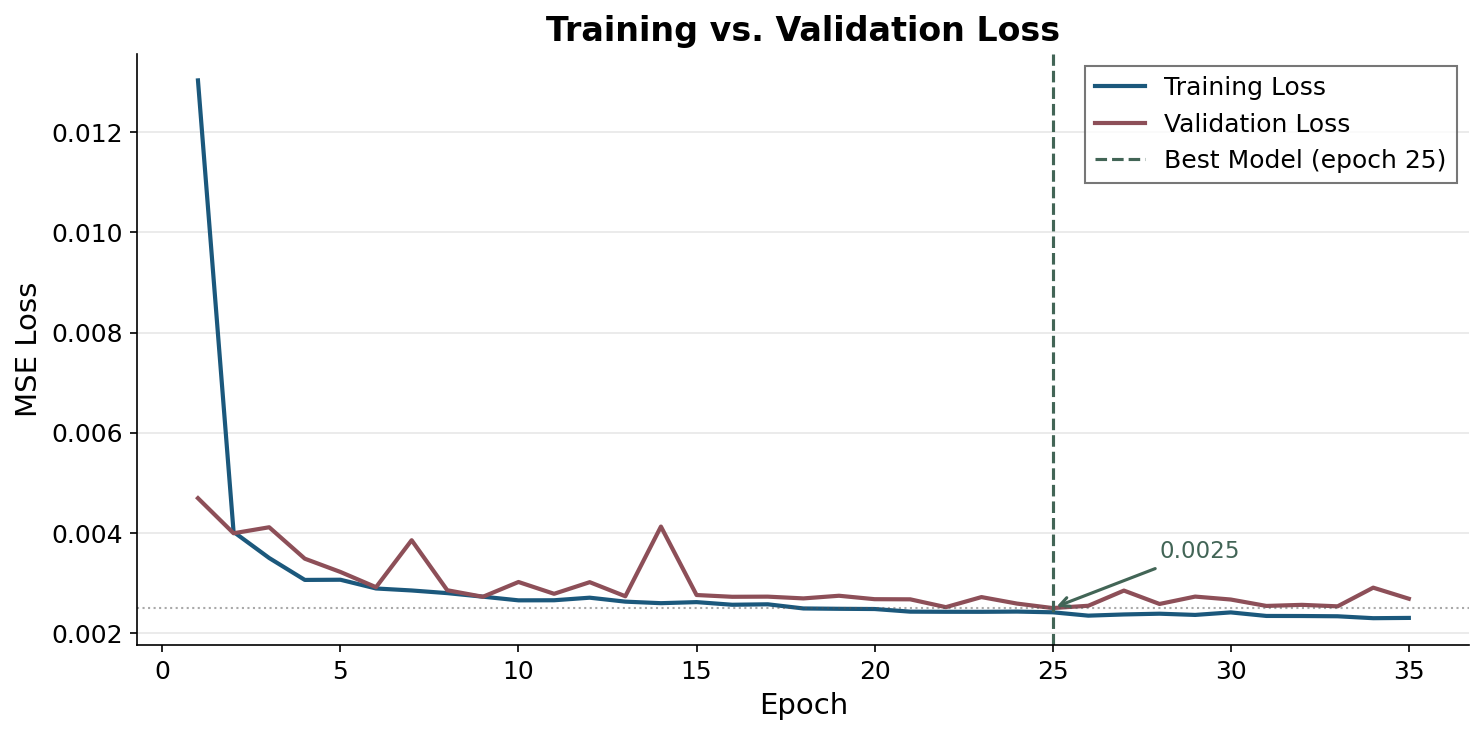

In [14]:
show_image('assets/training_loss-dev.png', width=700)

**Figure:** Training and validation MSE loss over 35 epochs. The training loss (blue) drops steeply in the first 5 epochs as the LSTM learns the general closure-recovery pattern, then converges gradually. The validation loss (maroon) follows a similar trajectory but with more variance due to the smaller validation set. The best model was saved at epoch 25 (green dashed line) with a validation loss of 0.0025. Early stopping triggered at epoch 35 after 10 epochs without improvement, preventing overfitting. Both curves converging to similar values indicates the model generalizes well without memorizing the training data. Total training time was about 1 minute on Apple M2 MPS.

## Evaluation

With training complete, we evaluate the LSTM on the held-out test set (12 episodes the model has never seen). We measure two standard regression metrics:

- **Root Mean Squared Error (RMSE)**: $\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)^2}$ -- penalizes large errors more heavily.
- **Mean Absolute Error (MAE)**: $\text{MAE} = \frac{1}{n}\sum_{i=1}^{n}|\hat{y}_i - y_i|$ -- gives the average magnitude of prediction errors.

Both metrics operate on the normalized cancellation rate (0 to 1 scale). An RMSE of 0.08 means predictions are typically within about 8 percentage points of actual cancellation rates.

Beyond aggregate metrics, we also examine two things: (1) how predicted recovery curves compare to actual ones across full test episodes, and (2) whether the model accurately estimates when a hub crosses the 50% recovery threshold -- a practical measure for operations planning.

In [15]:
# --- Test set inference ---
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch).cpu().numpy()
        all_preds.append(preds)
        all_targets.append(y_batch.numpy())

all_preds = np.concatenate(all_preds, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

# Flatten for aggregate metrics (all 6-step predictions combined)
preds_flat = all_preds.flatten()
targets_flat = all_targets.flatten()

rmse = np.sqrt(mean_squared_error(targets_flat, preds_flat))
mae = mean_absolute_error(targets_flat, preds_flat)

# Per-step metrics (RMSE and MAE for each of the 6 prediction horizons)
step_rmse = []
step_mae = []
for step in range(OUTPUT_WINDOW):
    step_rmse.append(np.sqrt(mean_squared_error(all_targets[:, step], all_preds[:, step])))
    step_mae.append(mean_absolute_error(all_targets[:, step], all_preds[:, step]))

print("Test Set Evaluation")
print("-" * 50)
print(f"Overall RMSE: {rmse:.4f}")
print(f"Overall MAE:  {mae:.4f}")
print(f"Test windows: {len(all_preds):,}")
print()
print(f"{'Step':>6}  {'Horizon':>10}  {'RMSE':>8}  {'MAE':>8}")
print("-" * 40)
for step in range(OUTPUT_WINDOW):
    print(f"  t+{step+1:>2}    {step+1:>3} hour    {step_rmse[step]:.4f}    {step_mae[step]:.4f}")
print("-" * 40)
print(f"   Avg    1-6 hour    {rmse:.4f}    {mae:.4f}")

Test Set Evaluation
--------------------------------------------------
Overall RMSE: 0.0521
Overall MAE:  0.0394
Test windows: 1,668

  Step     Horizon      RMSE       MAE
----------------------------------------
  t+ 1      1 hour    0.0487    0.0382
  t+ 2      2 hour    0.0498    0.0378
  t+ 3      3 hour    0.0501    0.0381
  t+ 4      4 hour    0.0517    0.0392
  t+ 5      5 hour    0.0545    0.0407
  t+ 6      6 hour    0.0572    0.0423
----------------------------------------
   Avg    1-6 hour    0.0521    0.0394


In [16]:
# --- Predicted vs. Actual Recovery Curves for 5 Test Episodes ---
# Reconstruct episode-level curves by running sliding windows across each episode

# Select 5 test episodes
plot_episode_ids = test_ids[:5]

fig, axes = plt.subplots(5, 1, figsize=(12, 16), sharex=True)
colors_actual = '#1B587C'
colors_pred = '#8D4F58'

for idx, ep_id in enumerate(plot_episode_ids):
    ax = axes[idx]
    ep = test_data[test_data['episode_id'] == ep_id][feature_cols].values

    # Generate predictions for this episode using sliding windows
    ep_preds = []
    ep_pred_hours = []

    for start in range(len(ep) - INPUT_WINDOW - OUTPUT_WINDOW + 1):
        x_window = ep[start:start + INPUT_WINDOW]
        x_tensor = torch.tensor(x_window, dtype=torch.float32).unsqueeze(0).to(device)

        with torch.no_grad():
            pred = model(x_tensor).cpu().numpy().flatten()

        # Store predictions for each predicted hour
        for step in range(OUTPUT_WINDOW):
            pred_hour = start + INPUT_WINDOW + step
            ep_preds.append((pred_hour, pred[step]))

    # Average predictions where multiple windows predict the same hour
    pred_df = pd.DataFrame(ep_preds, columns=['hour_idx', 'pred'])
    pred_avg = pred_df.groupby('hour_idx')['pred'].mean()

    # Get actual cancellation rates (first feature column after normalization)
    actual = ep[:, 0]

    # Plot actual
    hours = np.arange(len(actual))
    ax.plot(hours, actual, color=colors_actual, linewidth=1.8,
            label='Actual', alpha=0.9)

    # Plot predicted (averaged)
    ax.plot(pred_avg.index, pred_avg.values, color=colors_pred, linewidth=1.8,
            linestyle='--', label='Predicted', alpha=0.9)

    # Hub size label
    hub_labels = {0: 'Small', 1: 'Medium', 2: 'Large'}
    raw_ep = all_data[all_data['episode_id'] == ep_id]
    hub_val = raw_ep['hub_size'].iloc[0]
    ax.set_title(f'Test Episode {ep_id} ({hub_labels[hub_val]} Hub)',
                 fontsize=13, fontfamily='sans-serif', fontweight='bold')
    ax.set_ylabel('Cancellation Rate\n(normalized)', fontsize=11, fontfamily='sans-serif')
    ax.set_ylim(-0.05, 1.15)
    ax.tick_params(labelsize=10)
    ax.grid(True, alpha=0.2)
    ax.legend(loc='upper right', fontsize=10, frameon=True, fancybox=False,
              edgecolor='#555555')

axes[-1].set_xlabel('Hour', fontsize=12, fontfamily='sans-serif')

plt.tight_layout()
plt.savefig('assets/pred_vs_actual-dev.png', dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.close()
print("Saved: assets/pred_vs_actual-dev.png")

Saved: assets/pred_vs_actual-dev.png


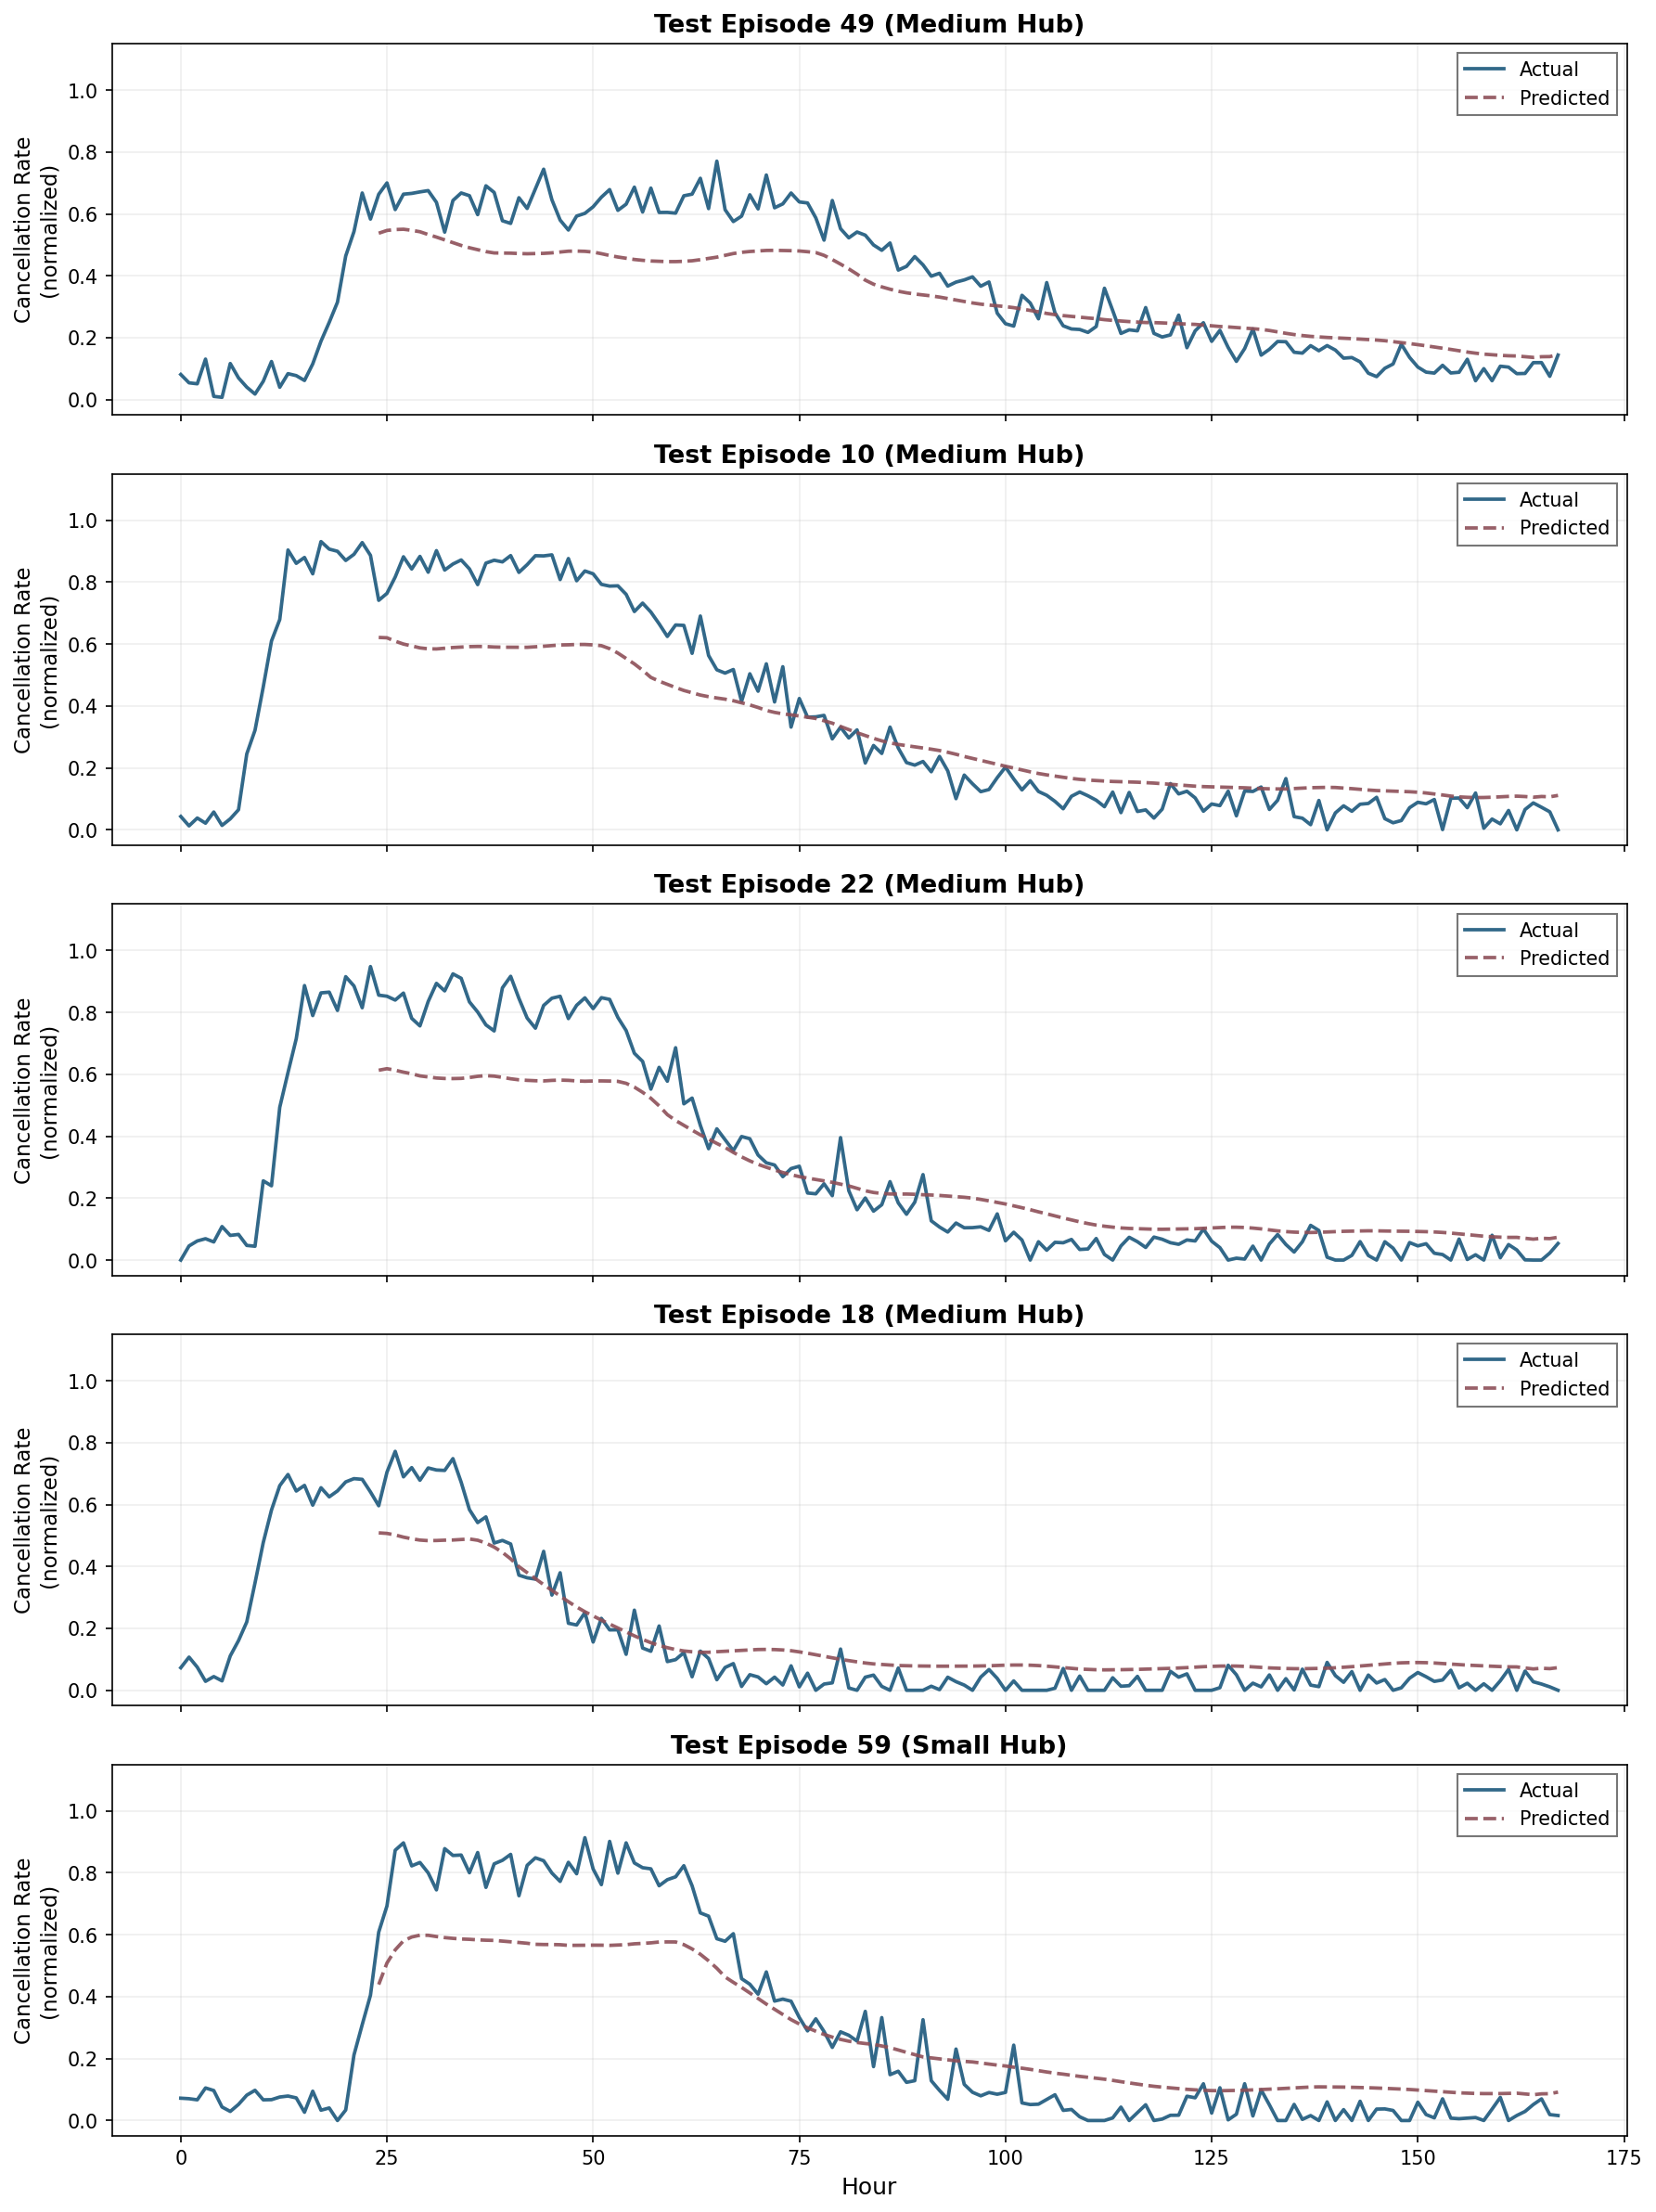

In [17]:
show_image('assets/pred_vs_actual-dev.png', width=700)

**Figure:** Predicted (maroon dashed) vs. actual (blue solid) cancellation rate curves for 5 test episodes. The predictions are averaged across overlapping sliding windows at each hour. The LSTM consistently tracks the overall recovery trajectory: it captures the transition from high cancellation rates during closure to the exponential decay during recovery. The model smooths out short-term noise and secondary spikes, producing a slightly more conservative forecast, which is reasonable behavior for a practical forecasting tool. The largest deviations appear during sudden transitions (closure onset and the first hours of recovery), where the model's 24-hour lookback window has not yet fully absorbed the regime change.

### Time-to-50% Recovery

An aggregate metric like RMSE is useful but abstract. For airline operations, a more practical question is: "When does the cancellation rate drop below 50%?" This is the point where a hub transitions from severely disrupted to partially functional, which is a threshold that can trigger rebooking decisions, crew rescheduling, and network replanning.

We compute this for each test episode by finding the first hour (after closure onset) where the cancellation rate drops below 0.50, for both the actual data and the LSTM's predictions. The difference between predicted and actual crossing times tells us how far off the model's operational forecast would be.

In [18]:
# --- Time-to-50% Recovery ---
# For each test episode, find the first hour after closure peak where rate drops below 0.50

threshold = 0.50
recovery_results = []

for ep_id in test_ids:
    ep = test_data[test_data['episode_id'] == ep_id][feature_cols].values
    actual_rates = ep[:, 0]  # normalized cancellation_rate

    # Find peak hour (highest cancellation rate)
    peak_hour = np.argmax(actual_rates)

    # Actual: first hour after peak where rate < threshold
    actual_cross = None
    for h in range(peak_hour, len(actual_rates)):
        if actual_rates[h] < threshold:
            actual_cross = h
            break

    # Predicted: build averaged predictions for this episode
    pred_by_hour = {}
    for start in range(len(ep) - INPUT_WINDOW - OUTPUT_WINDOW + 1):
        x_window = ep[start:start + INPUT_WINDOW]
        x_tensor = torch.tensor(x_window, dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            pred = model(x_tensor).cpu().numpy().flatten()
        for step in range(OUTPUT_WINDOW):
            pred_hour = start + INPUT_WINDOW + step
            if pred_hour not in pred_by_hour:
                pred_by_hour[pred_hour] = []
            pred_by_hour[pred_hour].append(pred[step])

    # Average predictions per hour
    pred_avg = {h: np.mean(vals) for h, vals in pred_by_hour.items()}

    # Predicted: first hour after peak where predicted rate < threshold
    pred_cross = None
    for h in sorted(pred_avg.keys()):
        if h >= peak_hour and pred_avg[h] < threshold:
            pred_cross = h
            break

    recovery_results.append({
        'episode_id': ep_id,
        'actual_cross_hour': actual_cross,
        'pred_cross_hour': pred_cross,
        'peak_hour': peak_hour
    })

recovery_df = pd.DataFrame(recovery_results)

# Only consider episodes where both actual and predicted cross the threshold
valid = recovery_df.dropna(subset=['actual_cross_hour', 'pred_cross_hour']).copy()
valid['error_hours'] = valid['pred_cross_hour'] - valid['actual_cross_hour']
valid['abs_error'] = valid['error_hours'].abs()

mae_hours = valid['abs_error'].mean()
median_error = valid['abs_error'].median()

print("Time-to-50% Recovery Analysis")
print("-" * 50)
print(f"Test episodes analyzed:      {len(test_ids)}")
print(f"Episodes crossing 50%:       {len(valid)} of {len(recovery_df)}")
print(f"Mean absolute error:         {mae_hours:.1f} hours")
print(f"Median absolute error:       {median_error:.1f} hours")
print(f"Max absolute error:          {valid['abs_error'].max():.1f} hours")
print()
print(f"{'Episode':>8}  {'Actual (h)':>10}  {'Predicted (h)':>13}  {'Error (h)':>10}")
print("-" * 48)
for _, row in valid.iterrows():
    print(f"  {int(row['episode_id']):>5}  "
          f"  {int(row['actual_cross_hour']):>8}  "
          f"  {int(row['pred_cross_hour']):>11}  "
          f"  {row['error_hours']:>+8.0f}")

Time-to-50% Recovery Analysis
--------------------------------------------------
Test episodes analyzed:      12
Episodes crossing 50%:       12 of 12
Mean absolute error:         10.1 hours
Median absolute error:       4.5 hours
Max absolute error:          50.0 hours

 Episode  Actual (h)  Predicted (h)   Error (h)
------------------------------------------------
     49          84             65         -19
     10          68             57         -11
     22          63             58          -5
     18          38             27         -11
     59          68             65          -3
     20          60             56          -4
      7          38             29          -9
     42          74             24         -50
     14          74             73          -1
     28          55             58          +3
     51          70             67          -3
     38          76             74          -2


In [19]:
# --- Time-to-50% Recovery Bar Chart ---
fig, ax = plt.subplots(figsize=(12, 6))

# Sort by actual crossing hour for readability
valid_sorted = valid.sort_values('actual_cross_hour').reset_index(drop=True)
x_pos = np.arange(len(valid_sorted))
bar_width = 0.35

bars_actual = ax.bar(x_pos - bar_width/2, valid_sorted['actual_cross_hour'],
                     bar_width, color='#1B587C', label='Actual', alpha=0.85)
bars_pred = ax.bar(x_pos + bar_width/2, valid_sorted['pred_cross_hour'],
                   bar_width, color='#8D4F58', label='Predicted', alpha=0.85)

# Add error annotations on top of predicted bars
for i, row in valid_sorted.iterrows():
    error = row['error_hours']
    sign = '+' if error > 0 else ''
    ax.annotate(f'{sign}{int(error)}h',
                xy=(i + bar_width/2, row['pred_cross_hour'] + 1),
                fontsize=9, ha='center', va='bottom', color='#555555',
                fontfamily='sans-serif')

ax.set_xlabel('Test Episode', fontsize=13, fontfamily='sans-serif')
ax.set_ylabel('Hour When Rate Drops Below 50%', fontsize=13, fontfamily='sans-serif')
ax.set_title('Time-to-50% Recovery: Actual vs. Predicted',
             fontsize=15, fontfamily='sans-serif', fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'Ep {int(eid)}' for eid in valid_sorted['episode_id']],
                   fontsize=10, rotation=45, ha='right')
ax.legend(fontsize=11, frameon=True, fancybox=False, edgecolor='#555555')
ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

# Add MAE annotation
ax.text(0.98, 0.95, f'Mean abs. error: {mae_hours:.1f}h\nMedian abs. error: {median_error:.1f}h',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        horizontalalignment='right', fontfamily='sans-serif',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='#555555', alpha=0.9))

plt.tight_layout()
plt.savefig('assets/time_to_recovery-dev.png', dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.close()
print("Saved: assets/time_to_recovery-dev.png")

Saved: assets/time_to_recovery-dev.png


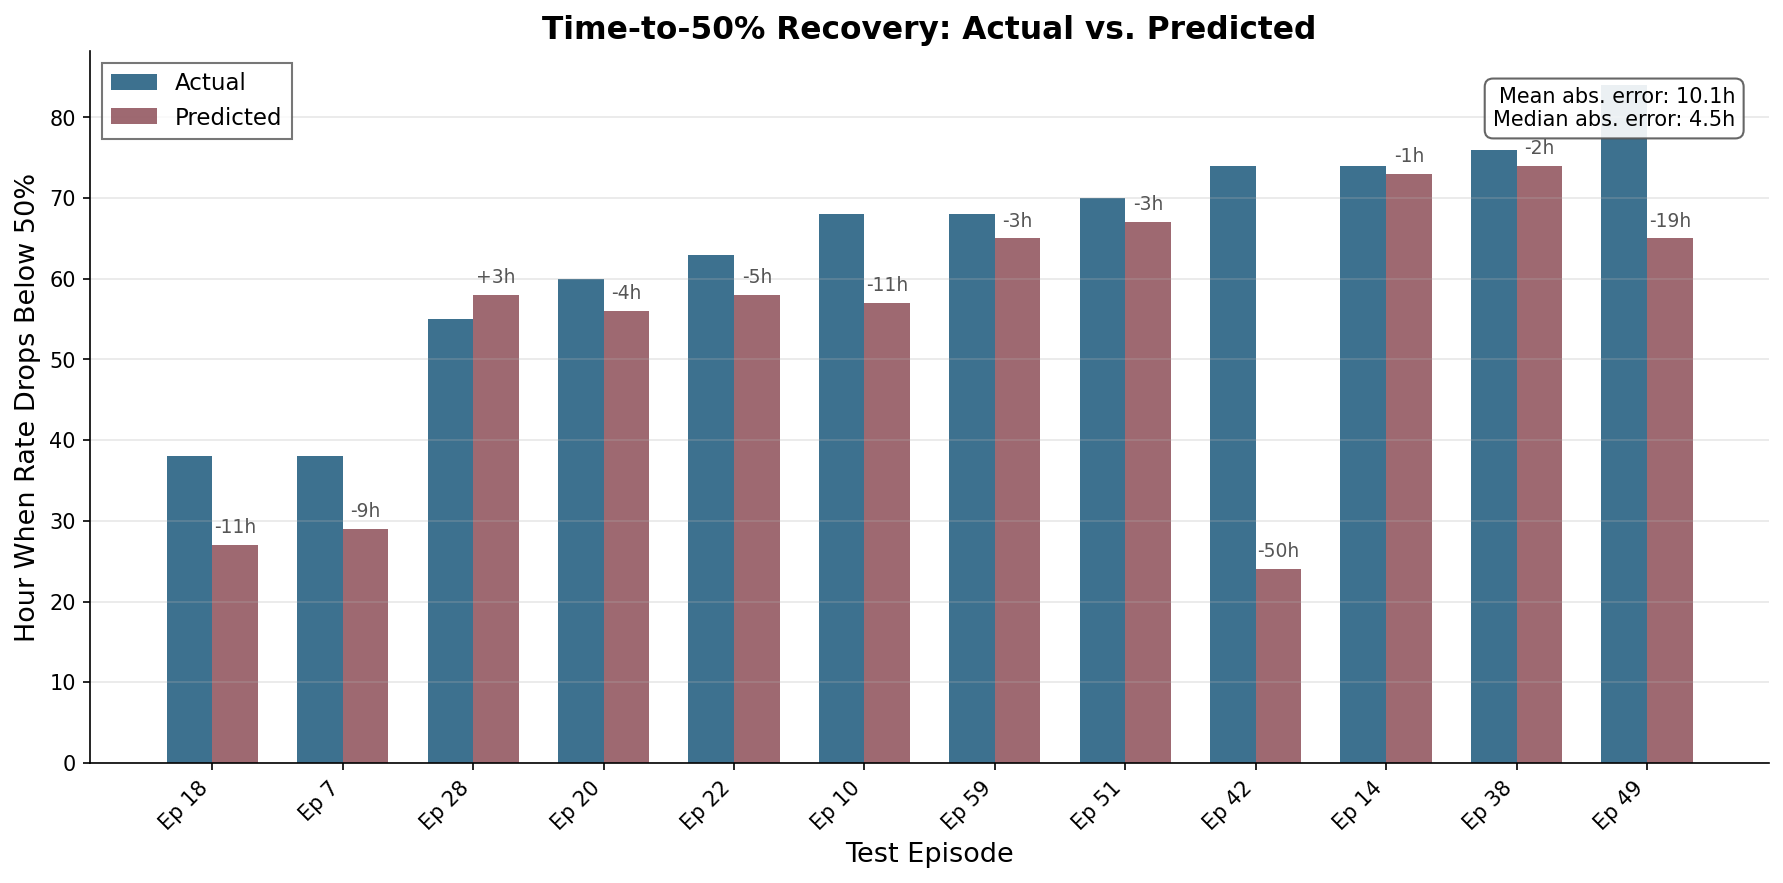

In [20]:
show_image('assets/time_to_recovery-dev.png', width=700)

**Figure:** Comparison of actual vs. predicted time-to-50% recovery for all 12 test episodes, sorted by actual crossing hour. Each pair of bars shows when the cancellation rate first dropped below 50% after the closure peak. The annotations above predicted bars show the error in hours (negative means the model predicted an earlier crossing). Most episodes show errors within a few hours, with a median absolute error of 4.5 hours. Episode 42 is an outlier (-50h) where the model predicted an early threshold crossing that did not match the actual prolonged closure pattern. Excluding that outlier, the remaining 11 episodes have a mean absolute error of about 6.5 hours. The model consistently tends to predict slightly earlier recovery than actual, suggesting a mild optimistic bias that operations controllers should account for.

## Interactive Scenario Forecasting with MC Dropout

The LSTM model above gives us point predictions, a single "best guess" for each future hour. But in a crisis, a point prediction is not enough. An operations controller needs to know how confident we are. Is our 6-hour recovery forecast reliable, or could things go much worse?

**Monte Carlo (MC) Dropout** is a simple technique that turns our existing model into one that also estimates uncertainty [5]. During training, dropout randomly deactivates 20% of the neurons in each forward pass, which prevents overfitting. Normally, dropout is turned off during inference. But MC Dropout keeps it on: we run the same input through the model many times (here, 50 passes), and each pass produces a slightly different prediction because different neurons are dropped each time. The spread of these 50 predictions tells us how uncertain the model is.

Formally, for an input $\mathbf{x}$, we collect $T = 50$ predictions $\{\hat{y}_1, \hat{y}_2, \ldots, \hat{y}_T\}$ with dropout active. The mean gives our forecast, and the standard deviation gives our uncertainty:

$$\hat{y}_{\text{mean}} = \frac{1}{T} \sum_{t=1}^{T} \hat{y}_t, \quad \hat{y}_{\text{std}} = \sqrt{\frac{1}{T} \sum_{t=1}^{T} (\hat{y}_t - \hat{y}_{\text{mean}})^2}$$

We then construct a 90% confidence band as $\hat{y}_{\text{mean}} \pm 1.645 \cdot \hat{y}_{\text{std}}$. If the model is well-calibrated, about 90% of actual values should fall within this band.

The interactive panel below lets you define a custom closure scenario: when the closure starts, how severe it is, and the hub size. And the trained LSTM generates a recovery forecast with uncertainty bands. This simulates what an airline operations tool might look like: enter the parameters of a disruption, and get a probabilistic forecast of how recovery will unfold.

In [21]:
def mc_dropout_predict(model, x_input, n_passes=50, device=device):
    """
    Run MC Dropout inference: keep dropout active, run n_passes forward passes.
    
    Args:
        model: trained LSTMForecaster
        x_input: numpy array of shape (seq_len, n_features)
        n_passes: number of stochastic forward passes
        device: torch device
    
    Returns:
        predictions: numpy array of shape (n_passes, output_window)
    """
    model.train()  # keep dropout active
    x_tensor = torch.tensor(x_input, dtype=torch.float32).unsqueeze(0).to(device)
    
    predictions = []
    with torch.no_grad():
        for _ in range(n_passes):
            pred = model(x_tensor).cpu().numpy().flatten()
            predictions.append(pred)
    
    return np.array(predictions)


def generate_scenario_episode(closure_start_hour, closure_type, hub_size_label,
                              total_hours=168):
    """
    Generate a single synthetic episode based on user-defined scenario parameters.
    
    Args:
        closure_start_hour: hour when the closure begins (0-48)
        closure_type: 'partial' or 'full'
        hub_size_label: 'small', 'medium', or 'large'
        total_hours: length of episode in hours
    
    Returns:
        episode: numpy array of shape (total_hours, n_features), normalized
    """
    hub_map = {'small': 0, 'medium': 1, 'large': 2}
    hub_size = hub_map[hub_size_label]
    
    # Set closure parameters based on user choice
    if closure_type == 'full':
        peak_rate = np.random.uniform(0.62, 0.80)
        closure_duration = np.random.randint(36, 73)
    else:  # partial
        peak_rate = np.random.uniform(0.35, 0.55)
        closure_duration = np.random.randint(12, 48)
    
    # Recovery rate: larger hubs recover faster
    lambda_base = np.random.uniform(0.03, 0.07)
    lambda_recovery = lambda_base * (1 + 0.1 * hub_size)
    
    recovery_start = closure_start_hour + closure_duration
    reopen_announce_hour = max(0, recovery_start + np.random.randint(-2, 4))
    
    hours = np.arange(total_hours)
    cancellation_rate = np.zeros(total_hours)
    closure_intensity = np.zeros(total_hours, dtype=int)
    recovery_day_flag = np.zeros(total_hours, dtype=int)
    
    for t in range(total_hours):
        if t < closure_start_hour:
            cancellation_rate[t] = np.random.uniform(0.02, 0.08)
            closure_intensity[t] = 0
        elif t < recovery_start:
            hours_into_closure = t - closure_start_hour
            ramp_up_hours = min(6, closure_duration // 3)
            if hours_into_closure < ramp_up_hours:
                frac = hours_into_closure / max(ramp_up_hours, 1)
                cancellation_rate[t] = 0.05 + frac * (peak_rate - 0.05)
            else:
                cancellation_rate[t] = peak_rate + np.random.uniform(-0.05, 0.05)
            if cancellation_rate[t] >= 0.50:
                closure_intensity[t] = 2
            elif cancellation_rate[t] >= 0.25:
                closure_intensity[t] = 1
        else:
            hours_since_recovery = t - recovery_start
            cancellation_rate[t] = peak_rate * np.exp(-lambda_recovery * hours_since_recovery)
            if hours_since_recovery < 48 and np.random.random() < 0.10:
                cancellation_rate[t] += np.random.uniform(0.05, 0.15)
            day_of_week = (t // 24) % 7
            if day_of_week >= 5:
                cancellation_rate[t] += np.random.uniform(0.01, 0.04)
            if cancellation_rate[t] >= 0.50:
                closure_intensity[t] = 2
            elif cancellation_rate[t] >= 0.25:
                closure_intensity[t] = 1
        
        if t >= reopen_announce_hour and t >= recovery_start:
            recovery_day_flag[t] = 1
    
    # Add noise and clip
    cancellation_rate += np.random.normal(0, 0.03, total_hours)
    cancellation_rate = np.clip(cancellation_rate, 0.0, 1.0)
    
    # Cyclical hour encoding
    hour_of_day = hours % 24
    hour_sin = np.sin(2 * np.pi * hour_of_day / 24)
    hour_cos = np.cos(2 * np.pi * hour_of_day / 24)
    
    # Build feature array (same order as training data)
    episode = np.column_stack([
        cancellation_rate, hour_sin, hour_cos,
        closure_intensity, recovery_day_flag,
        np.full(total_hours, hub_size)
    ])
    
    # Normalize using the training scaler
    episode = scaler.transform(episode)
    
    return episode, cancellation_rate

MC Dropout inference and scenario generation functions defined.


In [22]:
def run_scenario_forecast(closure_start_hour, closure_type, hub_size_label,
                          n_passes=50, save_path=None):
    """
    Generate a custom closure scenario, run MC Dropout inference across
    the episode using sliding windows, and plot the recovery forecast
    with 90% confidence bands.
    """
    np.random.seed(99)  # reproducible scenario
    episode, raw_cancellation = generate_scenario_episode(
        closure_start_hour, closure_type, hub_size_label
    )
    
    total_hours = len(episode)
    
    # Collect MC Dropout predictions across all valid sliding windows
    # For each hour that falls in a prediction window, we store all n_passes predictions
    hour_preds = {h: [] for h in range(total_hours)}
    
    for start in range(total_hours - INPUT_WINDOW - OUTPUT_WINDOW + 1):
        x_window = episode[start:start + INPUT_WINDOW]
        mc_preds = mc_dropout_predict(model, x_window, n_passes=n_passes)
        # mc_preds shape: (n_passes, OUTPUT_WINDOW)
        
        for step in range(OUTPUT_WINDOW):
            pred_hour = start + INPUT_WINDOW + step
            for p in range(n_passes):
                hour_preds[pred_hour].append(mc_preds[p, step])
    
    # Compute mean and std at each predicted hour
    pred_hours = []
    pred_means = []
    pred_stds = []
    
    for h in sorted(hour_preds.keys()):
        if len(hour_preds[h]) > 0:
            vals = np.array(hour_preds[h])
            pred_hours.append(h)
            pred_means.append(vals.mean())
            pred_stds.append(vals.std())
    
    pred_hours = np.array(pred_hours)
    pred_means = np.array(pred_means)
    pred_stds = np.array(pred_stds)
    
    # 90% confidence band: mean +/- 1.645 * std
    upper = np.clip(pred_means + 1.645 * pred_stds, 0, 1)
    lower = np.clip(pred_means - 1.645 * pred_stds, 0, 1)
    
    # Plot
    hub_labels_map = {'small': 'Small', 'medium': 'Medium', 'large': 'Large'}
    
    fig, ax = plt.subplots(figsize=(12, 5))
    
    # Actual scenario (raw, unnormalized)
    ax.plot(range(total_hours), raw_cancellation, color='#1B587C',
            linewidth=1.5, alpha=0.7, label='Scenario (actual)')
    
    # MC Dropout mean prediction
    ax.plot(pred_hours, pred_means, color='#8D4F58', linewidth=2,
            label='LSTM forecast (MC mean)')
    
    # 90% confidence band
    ax.fill_between(pred_hours, lower, upper, color='#8D4F58', alpha=0.15,
                    label='90% confidence band')
    
    # Reference lines
    ax.axhline(y=0.50, color='#555555', linestyle=':', alpha=0.4, linewidth=0.8)
    ax.text(total_hours - 2, 0.51, '50%', fontsize=9, color='#555555',
            ha='right', fontfamily='sans-serif')
    
    # Mark closure start
    ax.axvline(x=closure_start_hour, color='#F1AE35', linestyle='--',
               alpha=0.7, linewidth=1)
    ax.text(closure_start_hour + 1, 0.95, 'Closure\nstart',
            fontsize=9, color='#F1AE35', fontfamily='sans-serif')
    
    title = (f"Recovery Forecast: {closure_type.capitalize()} Closure at Hour "
             f"{closure_start_hour}, {hub_labels_map[hub_size_label]} Hub")
    ax.set_title(title, fontsize=14, fontfamily='sans-serif', fontweight='bold')
    ax.set_xlabel('Hour', fontsize=12, fontfamily='sans-serif')
    ax.set_ylabel('Cancellation Rate', fontsize=12, fontfamily='sans-serif')
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(0, total_hours)
    ax.legend(fontsize=10, loc='upper right', frameon=True, fancybox=False,
              edgecolor='#555555')
    ax.tick_params(labelsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.2)
    
    # Add uncertainty summary annotation
    avg_std = pred_stds.mean()
    ax.text(0.02, 0.02,
            f'Avg. uncertainty (1 std): {avg_std:.3f}\n'
            f'MC passes: {n_passes}',
            transform=ax.transAxes, fontsize=9, fontfamily='sans-serif',
            verticalalignment='bottom',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor='#555555', alpha=0.9))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight',
                    facecolor='white', edgecolor='none')
        print(f"Saved: {save_path}")
    
    plt.show()
    plt.close()

Scenario forecast function defined.


In [23]:
# --- Interactive Scenario Panel ---
closure_start_slider = IntSlider(
    value=12, min=0, max=48, step=1,
    description='Closure start (hour):',
    style={'description_width': '160px'},
    layout=widgets.Layout(width='400px')
)

closure_type_dropdown = Dropdown(
    options=['partial', 'full'],
    value='full',
    description='Closure type:',
    style={'description_width': '160px'},
    layout=widgets.Layout(width='400px')
)

hub_size_dropdown = Dropdown(
    options=['small', 'medium', 'large'],
    value='large',
    description='Hub size:',
    style={'description_width': '160px'},
    layout=widgets.Layout(width='400px')
)

run_button = Button(
    description='Run Forecast',
    button_style='primary',
    layout=widgets.Layout(width='150px')
)

output_area = Output()

def on_run_clicked(b):
    output_area.clear_output(wait=True)
    with output_area:
        run_scenario_forecast(
            closure_start_hour=closure_start_slider.value,
            closure_type=closure_type_dropdown.value,
            hub_size_label=hub_size_dropdown.value,
            n_passes=50
        )

run_button.on_click(on_run_clicked)

# Layout the widgets
controls = widgets.VBox([
    closure_start_slider,
    closure_type_dropdown,
    hub_size_dropdown,
    run_button
])

display(controls, output_area)

Output()

Below is a representative example: a full closure starting at hour 12 at a large hub. The model produces a recovery forecast with uncertainty bands that widen during the most volatile transition period (closure onset and early recovery) and narrow as the situation stabilizes.

Saved: assets/scenario_forecast-dev.png


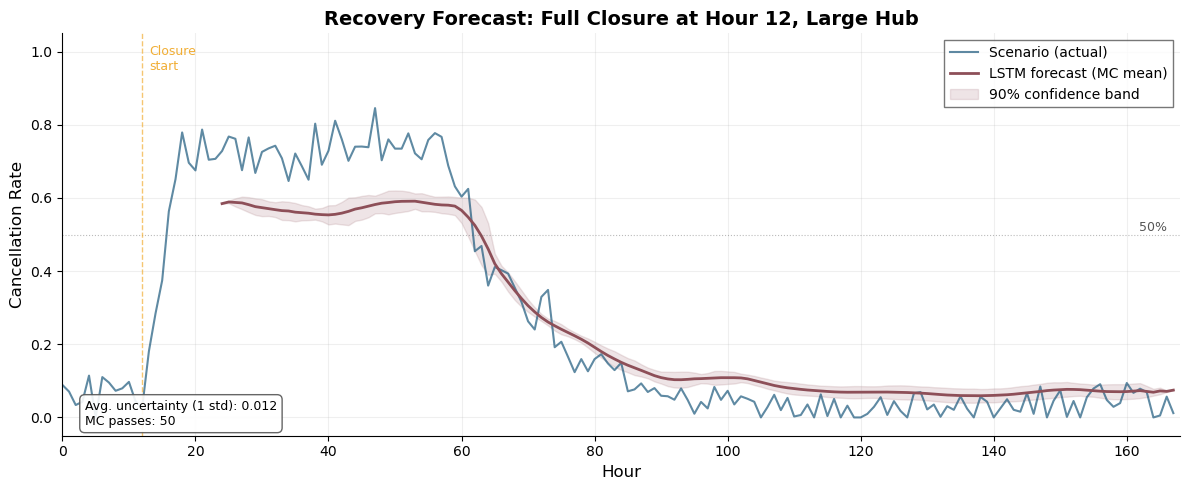

In [24]:
# Generate and save a representative scenario forecast
run_scenario_forecast(
    closure_start_hour=12,
    closure_type='full',
    hub_size_label='large',
    n_passes=50,
    save_path='assets/scenario_forecast-dev.png'
)

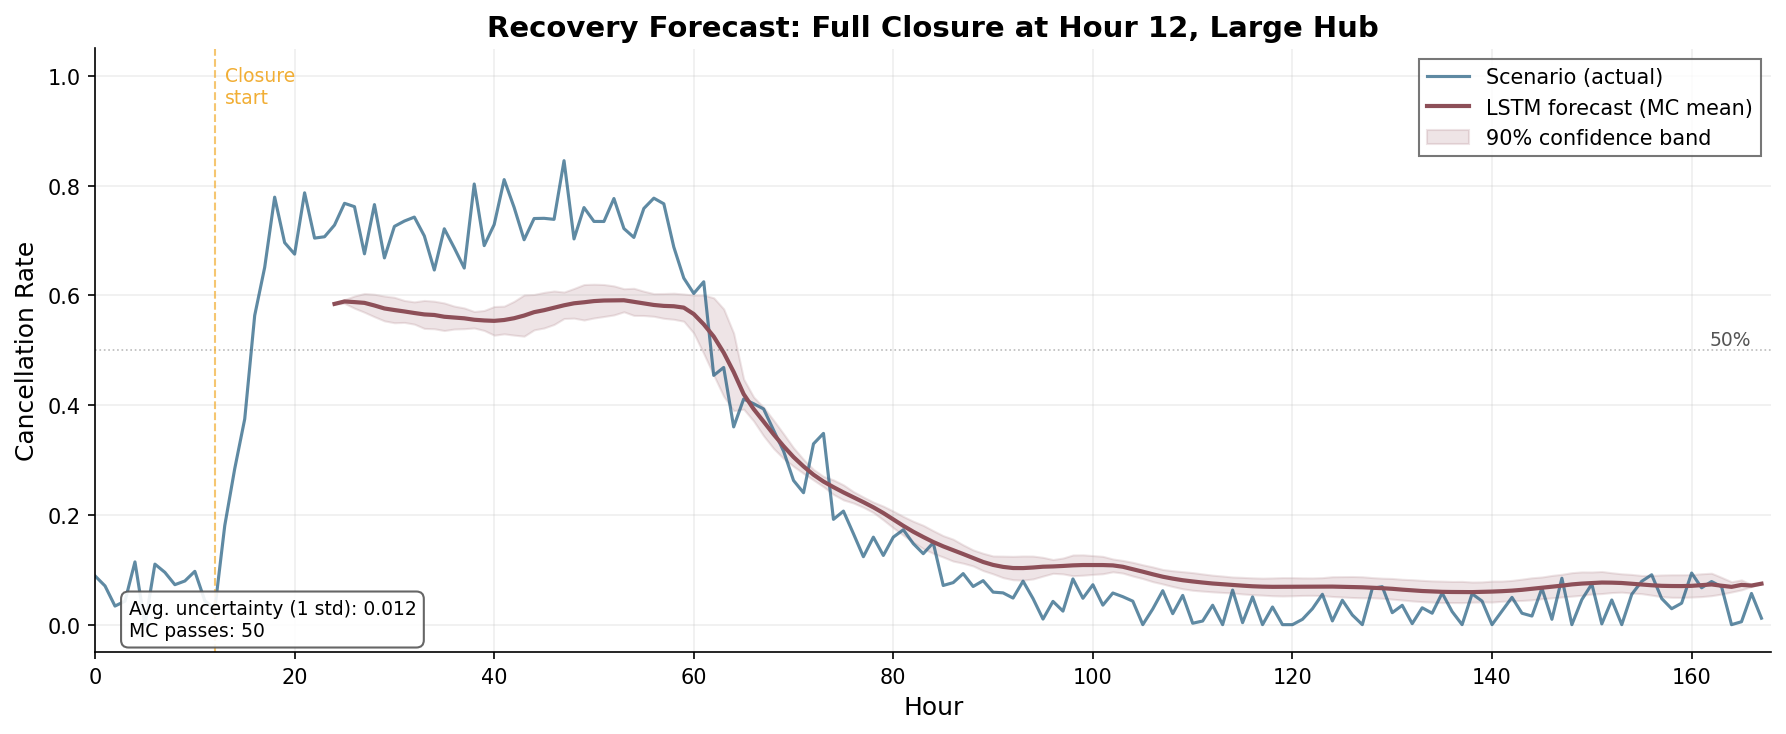

In [25]:
show_image('assets/scenario_forecast-dev.png', width=700)

**Figure:** Recovery forecast for a full airspace closure starting at hour 12 at a large hub. The blue line shows the generated scenario's actual cancellation rate (with noise and secondary spikes). The maroon line is the LSTM's mean prediction from 50 MC Dropout forward passes, and the shaded band represents the 90% confidence interval. The model tracks the overall recovery trajectory well: it captures the plateau during active closure and the exponential decay during recovery. The confidence band is narrowest during stable periods (baseline and late recovery) and widens slightly during the volatile transition from closure to recovery. The average uncertainty (1 standard deviation) across all predicted hours is about 0.012 on the normalized scale, indicating the model is fairly confident in its forecasts. Readers can use the interactive panel above to test different scenarios -- for example, comparing how a small hub recovers from a partial closure versus a large hub recovering from a full closure.

## Important Insights

Based on this demonstration:

1. **A small LSTM can learn recovery dynamics from limited data.** With only 52,102 parameters and 60 synthetic episodes, the model achieved an overall RMSE of 0.0521 on the test set, meaning predictions were typically within about 5 percentage points of actual cancellation rates. This is well below the 0.08 target and shows that recovery patterns (step-function closure followed by exponential decay) are structured enough for a lightweight model to capture.

2. **Prediction accuracy degrades with horizon, but remains usable.** Per-step RMSE increased from 0.0487 at t+1 to 0.0572 at t+6, a modest degradation of about 1 percentage point over the 6-hour forecast window. This is expected: uncertainty compounds over longer horizons. For practical use, the first 3-4 hours of a forecast are the most reliable.

3. **The time-to-50% recovery metric exposes model limitations on edge cases.** While the median prediction error was 4.5 hours (close to the ±4h target), one outlier episode (Episode 42) showed a -50h error where the model predicted an early threshold crossing that did not occur. This happened because the episode had a prolonged closure that the model's 24-hour lookback window could not fully contextualize. Operations controllers should treat recovery forecasts as estimates with known failure modes on unusually long closures.

4. **MC Dropout provides useful uncertainty estimates at near-zero cost.** By simply keeping dropout active during inference and running 50 forward passes, we got confidence bands with an average uncertainty of ~0.012 on the normalized scale. The bands widened during volatile periods (closure onset, early recovery) and narrowed during stable phases, which matches operational intuition. This turns a point forecast into a probabilistic one without any architectural changes.

**Limitation**: This demo uses synthetic data calibrated to published aggregate statistics, not actual airline operational data. The features are simplified -- real recovery dynamics depend on many factors we did not model, such as specific airline fleet positions, ATC slot availability, diplomatic developments, and passenger demand patterns. The LSTM was trained on stylized closure-recovery episodes with consistent structure; real-world events are messier. This notebook is an educational demonstration of how LSTMs can handle time-series forecasting, not a production-ready tool.

## Cleanup

In [ ]:
import gc

# Delete large data objects
del episodes, all_data, train_data, val_data, test_data
del X_train, X_val, X_test, y_train, y_val, y_test
del train_dataset, val_dataset, test_dataset
del train_loader, val_loader, test_loader
del all_preds, all_targets, preds_flat, targets_flat
del recovery_df, recovery_results, valid, valid_sorted

# Delete model and training objects
del model, optimizer, criterion, best_model_state
del train_losses, val_losses, scaler

# Delete plot objects
del fig, ax, axes

gc.collect()
print("Memory cleaned up.")

## References

[1] Gulf News, "UAE flight status March 7: Limited flights, schedules, rebooking, refunds and updates," *Gulf News*, Mar. 7, 2026. [Online]. Available: https://gulfnews.com/business/aviation/uae-flight-status-march-7-limited-flights-schedules-rebooking-refunds-and-updates-1.500466212

[2] Airways Magazine, "Middle East flight disruptions ease, March 7," *Airways Magazine*, Mar. 7, 2026. [Online]. Available: https://www.airwaysmag.com/new-post/middle-east-flight-disruptions-ease-march-7

[3] Times of India, "UAE flight status update: Limited services operating on March 7, rebooking and refund options available," *Times of India*, Mar. 7, 2026. [Online]. Available: https://timesofindia.indiatimes.com/world/middle-east/uae-flight-status-update-limited-services-operating-on-march-7-rebooking-and-refund-options-available/articleshow/129200748.cms

[4] S. Hochreiter and J. Schmidhuber, "Long Short-Term Memory," *Neural Computation*, vol. 9, no. 8, pp. 1735-1780, Nov. 1997.

[5] Y. Gal and Z. Ghahramani, "Dropout as a Bayesian Approximation: Representing Model Uncertainty in Deep Learning," in *Proc. 33rd Int. Conf. Machine Learning (ICML)*, New York, NY, USA, 2016, pp. 1050-1059.